<a href="https://colab.research.google.com/github/adamimmanuel/Well-Analyst/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving volve production data set (1).xlsx to volve production data set (1) (1).xlsx
User uploaded file "volve production data set (1) (1).xlsx" with length 1266918 bytes


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt   #adam
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_excel("volve production data set (1).xlsx")

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   15634 non-null  object 
 1   NPD_WELL_BORE_NAME        15634 non-null  object 
 2   ON_STREAM_HRS             15349 non-null  float64
 3   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 4   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 5   AVG_DP_TUBING             8980 non-null   float64
 6   AVG_ANNULUS_PRESS         7890 non-null   float64
 7   AVG_CHOKE_SIZE_P          8919 non-null   float64
 8   AVG_WHP_P                 9155 non-null   float64
 9   AVG_WHT_P                 9146 non-null   float64
 10  DP_CHOKE_SIZE             15340 non-null  float64
 11  BORE_OIL_VOL              9161 non-null   float64
 12  BORE_GAS_VOL              9161 non-null   float64
 13  BORE_WAT_VOL              9161 non-null   float64
 14  BORE_W

In [ ]:
df.head()

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,07-Apr-14,15/9-F-1 C,0.0,0.000,0.000,0.000,0.0,0.00000,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
1,08-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.00306,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
2,09-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.97901,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
3,10-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.54576,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
4,11-Apr-14,15/9-F-1 C,0.0,310.376,96.876,277.278,0.0,1.21599,33.098,10.48,33.072,0.0,0.0,0.0,NaN,production


In [ ]:
def clean_data(data):
    data = data.copy()
    data['DATEPRD'] = pd.to_datetime(data['DATEPRD'], errors='coerce')
    data = data.fillna(0)

    return data


df_clean = clean_data(df)
display(df_clean)

/tmp/ipykernel_2615/623742576.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['DATEPRD'] = pd.to_datetime(data['DATEPRD'], errors='coerce')


,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production


In [ ]:
def clean_data(data):
    data = data.dropna()  # Menghapus data kosong
    data['Date'] = pd.to_datetime(data['Date']) # Mengubah kolom tanggal menjadi tipe datetime
    return data
display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production


In [ ]:
import sys #batas maksimum memori atau ukuran data yang bisa ditampilkan
np.set_printoptions(threshold=sys.maxsize) #menampilkan semua data
ma = np.convolve(df_clean['BORE_GAS_VOL'], np.ones(2)/2, mode='valid')
print(ma)

[0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 4.521950e+04
 1.280795e+05 1.937135e+05 1.998855e+05 1.853330e+05 1.935490e+05
 1.936980e+05 1.889000e+05 1.810040e+05 1.758585e+05 1.647400e+05
 1.514005e+05 1.436540e+05 1.381790e+05 1.409650e+05 1.399750e+05
 1.312825e+05 7.594400e+04 3.824300e+04 8.494750e+04 1.144850e+05
 1.091910e+05 1.050125e+05 1.048130e+05 1.058045e+05 1.074710e+05
 1.137330e+05 1.134525e+05 1.094395e+05 1.071775e+05 1.060545e+05
 1.075975e+05 1.082330e+05 1.070985e+05 1.061620e+05 1.061570e+05
 1.040250e+05 1.025370e+05 1.034010e+05 1.048695e+05 1.063985e+05
 8.764950e+04 8.656450e+04 1.045500e+05 1.018755e+05 9.968350e+04
 1.000780e+05 1.001325e+05 6.743750e+04 6.508900e+04 1.020275e+05
 1.126740e+05 1.184315e+05 1.178410e+05 1.157160e+05 1.136055e+05
 1.091020e+05 1.067540e+05 1.061425e+05 1.053445e+05 1.045085e+05
 1.032870e

In [ ]:
change = np.diff(df_clean['BORE_GAS_VOL']) #nilai kelipatan dari nilai sebelumnya
print(change)

[ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  9.04390e+04
  7.52810e+04  5.59870e+04 -4.36430e+04  1.45380e+04  1.89400e+03
 -1.59600e+03 -8.00000e+03 -7.79200e+03 -2.49900e+03 -1.97380e+04
 -6.94100e+03 -8.55200e+03 -2.39800e+03  7.97000e+03 -9.95000e+03
 -7.43500e+03 -1.03242e+05  2.78400e+04  6.55690e+04 -6.49400e+03
 -4.09400e+03 -4.26300e+03  3.86400e+03 -1.88100e+03  5.21400e+03
  7.31000e+03 -7.87100e+03 -1.55000e+02 -4.36900e+03  2.12300e+03
  9.63000e+02  3.08000e+02 -2.57700e+03  7.04000e+02 -7.14000e+02
 -3.55000e+03  5.74000e+02  1.15400e+03  1.78300e+03  1.27500e+03
 -3.87730e+04  3.66030e+04 -6.32000e+02 -4.71700e+03  3.33000e+02
  4.56000e+02 -3.47000e+02 -6.50430e+04  6.03460e+04  1.35310e+04
  7.76200e+03  3.75300e+03 -4.93400e+03  6.84000e+02 -4.90500e+03
 -4.10200e+03 -5.94000e+02 -6.29000e+02 -9.67000e+02 -7.05000e+02
 -1.73800e

In [ ]:
df_clean['BORE_OIL_VOL'] = df_clean['BORE_OIL_VOL'].fillna(0)

# Hitung nilai rata-rata
rata_rata_OIL = df_clean['BORE_OIL_VOL'].mean()

print("Rata-rata MINYAK", rata_rata_OIL)

Rata-rata MINYAK 642.0071638736088


In [ ]:
df_clean['BORE_GAS_VOL'] = df_clean['BORE_GAS_VOL'].fillna(0)

# Hitung nilai rata-rata
rata_rata_gas = df_clean['BORE_GAS_VOL'].mean()

print("Rata-rata GAS", rata_rata_gas)

Rata-rata GAS 94369.35314059102


In [ ]:
def BORE_GAS_Definition (row):
    gas_bbl = row['BORE_GAS_VOL'] * 6.28981

    if pd.isna(gas_bbl) or gas_bbl == 0.0:
        return 'No Production'

    if gas_bbl > 1000000:
        return 'High Production'
    elif 500000 <= gas_bbl <= 1000000:
        return 'Medium Production'
    elif gas_bbl < 500000:
        return 'Low Production'

    return 'Undefined' #pelabelan nilai volume gas

df_clean['BORE_GAS_Definition'] = df_clean.apply(BORE_GAS_Definition, axis=1)
display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,BORE_GAS_Definition
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,No Production
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,No Production
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,No Production
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,No Production
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production,No Production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production,No Production
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production,No Production
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production,No Production
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production,No Production


In [ ]:
df.describe()

,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL
count,15349.000000,8980.000000,8980.000000,8980.000000,7890.000000,8919.000000,9155.000000,9146.00000,15340.000000,9161.000000,9161.000000,9161.000000,5706.000000
mean,19.994172,181.803870,77.162970,154.028791,14.856100,55.168534,45.377815,67.72844,11.441063,1095.638031,161049.063094,1672.152931,5315.479145
std,8.369911,109.712365,45.657949,76.752381,8.406821,36.692924,24.752635,27.71903,19.816930,1323.541545,188136.409296,1706.980951,2181.487231
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-458.000000,0.000000
25%,24.000000,0.000000,0.000000,83.665000,10.841250,18.952990,31.148000,56.57775,0.000000,191.000000,29431.000000,20.000000,4338.250000
50%,24.000000,232.897000,103.186500,175.589000,16.308500,52.096880,37.934000,80.07150,2.385000,558.000000,87750.000000,1098.000000,5504.500000
75%,24.000000,255.401250,106.277000,204.320000,21.306500,99.924290,57.101500,88.06200,13.765250,1345.000000,202482.000000,3261.000000,6780.750000
max,25.000000,397.589000,108.502000,345.907000,30.020000,100.000000,137.311000,93.51000,125.719000,5902.000000,851132.000000,8020.000000,10014.000000


In [ ]:
# covert to Bbl
def convert_to_barrels(volume_m3):
    return volume_m3 * 6.28981
display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production


In [ ]:
#water cut new row
df['Water_Cut'] = df['BORE_WAT_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])
display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production


In [ ]:
def tentukan_status_water_cut(row):
    nilai_wc = row['Water_Cut']

    if pd.isna(nilai_wc):
        nilai_wc = 0
    if nilai_wc < 0.1:
        return 'Low'
    else:
        return 'High'

df_clean['Water_Cut'] = df_clean['BORE_WAT_VOL'] / (df_clean['BORE_OIL_VOL'] + df_clean['BORE_WAT_VOL'])

df_clean['Status_Water_Cut'] = df_clean.apply(tentukan_status_water_cut, axis=1)
display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,Water_Cut,Status_Water_Cut
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production,NaN,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production,NaN,Low
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production,NaN,Low
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production,NaN,Low
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production,NaN,Low


In [ ]:
df_clean['GOR'] = df_clean['BORE_GAS_VOL'] / (df_clean['BORE_OIL_VOL'])
display(df_clean) #adit

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,Water_Cut,Status_Water_Cut,GOR
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production,NaN,Low,NaN
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production,NaN,Low,NaN


In [ ]:
def tentukan_status_gor(row):
    nilai_gor = row['GOR']
    if pd.isna(nilai_gor):
        nilai_gor = 0
    if nilai_gor < 100:
        return 'Low'
    else:
        return 'High'

df_clean['Status_GOR'] = df_clean.apply(tentukan_status_gor, axis=1)

display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,Water_Cut,Status_Water_Cut,GOR,Status_GOR
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production,NaN,Low,NaN,Low


In [ ]:
display(df_clean)

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,Water_Cut,Status_Water_Cut
0,2014-04-07,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.00000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
1,2014-04-08,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,1.00306,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
2,2014-04-09,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.97901,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
3,2014-04-10,15/9-F-1 C,0.0,0.000,0.000,0.000,0.000,0.54576,0.000,0.000,0.000,0.0,0.0,0.0,0.0,production,NaN,Low
4,2014-04-11,15/9-F-1 C,0.0,310.376,96.876,277.278,0.000,1.21599,33.098,10.480,33.072,0.0,0.0,0.0,0.0,production,NaN,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,0.0,0.000,0.000,0.000,0.273,0.63609,0.078,0.229,0.019,0.0,0.0,0.0,0.0,production,NaN,Low
15630,2016-09-15,15/9-F-5,0.0,0.000,0.000,0.000,0.287,0.67079,0.085,0.229,0.006,0.0,0.0,0.0,0.0,production,NaN,Low
15631,2016-09-16,15/9-F-5,0.0,0.000,0.000,0.000,0.286,0.66439,0.085,0.229,0.012,0.0,0.0,0.0,0.0,production,NaN,Low
15632,2016-09-17,15/9-F-5,0.0,0.000,0.000,0.000,0.272,0.62466,0.075,0.228,0.026,0.0,0.0,0.0,0.0,production,NaN,Low


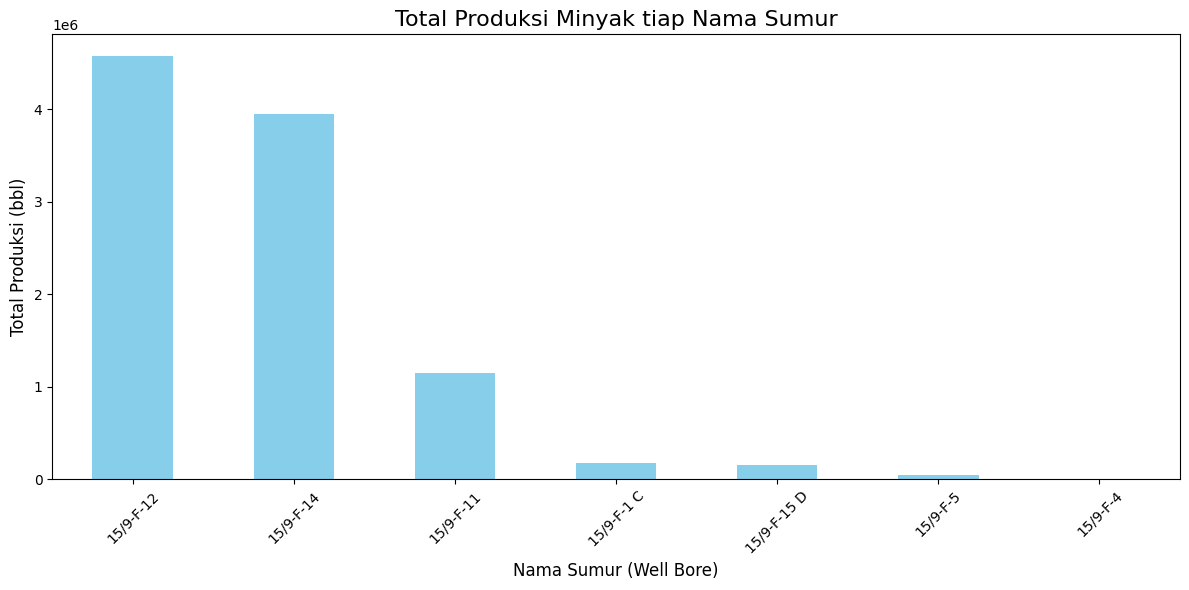

In [ ]:
plt.figure(figsize=(12, 6))
top_wells = df.groupby('NPD_WELL_BORE_NAME')['BORE_OIL_VOL'].sum().sort_values(ascending=False) #short value (dari data terbesar)
top_wells.plot(kind='bar' , color='skyblue')

plt.title('Total Produksi Minyak tiap Nama Sumur', fontsize=16)
plt.xlabel('Nama Sumur (Well Bore)', fontsize=12)
plt.ylabel('Total Produksi (bbl)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

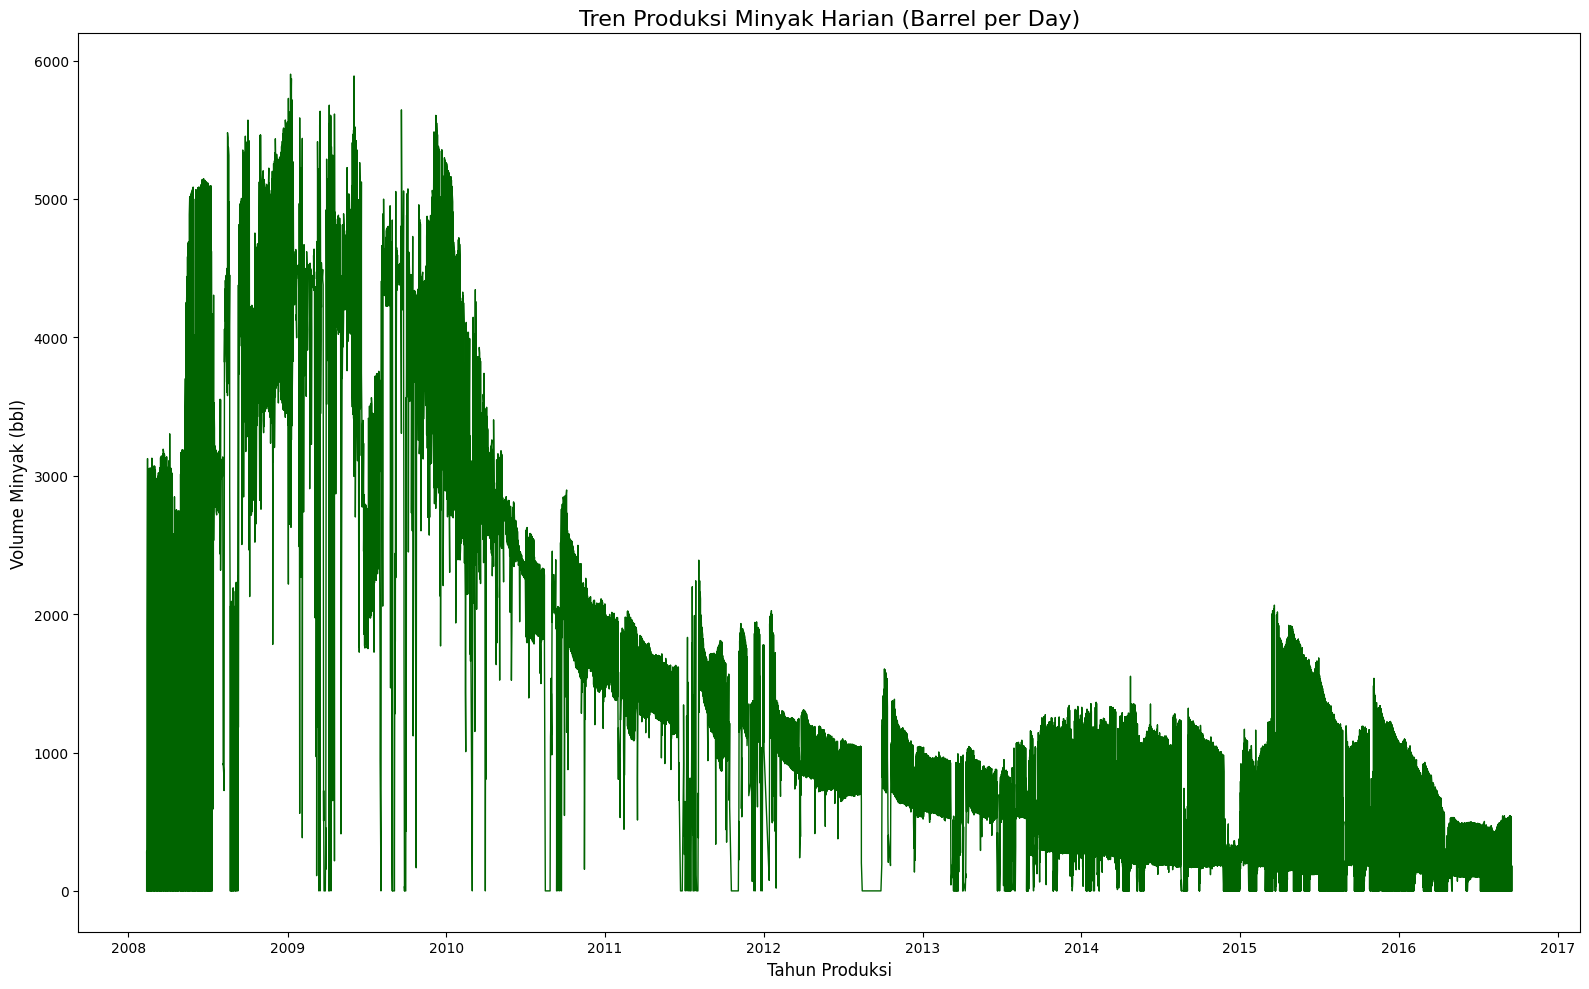

In [ ]:
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'], errors='coerce')
plt.figure(figsize=(16, 10))
df_plot = df.dropna(subset=['DATEPRD', 'BORE_OIL_VOL']).sort_values('DATEPRD')

plt.plot(df_plot['DATEPRD'], df_plot['BORE_OIL_VOL'], color='darkgreen', linewidth=1)
plt.title('Tren Produksi Minyak Harian (Barrel per Day)', fontsize=16)
plt.xlabel('Tahun Produksi', fontsize=12)
plt.ylabel('Volume Minyak (bbl)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11630/2104405809.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


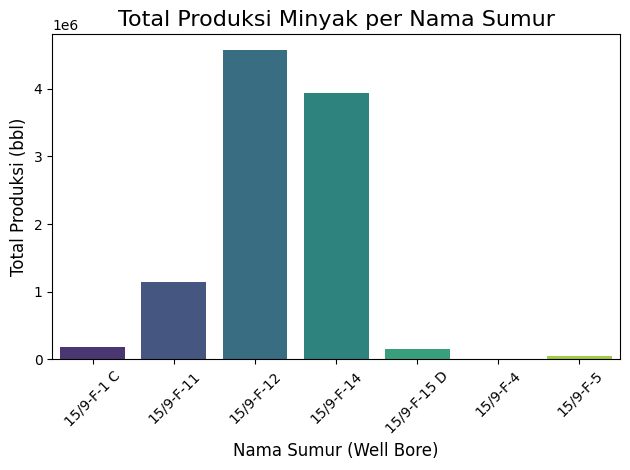

In [ ]:
sns.barplot(
    data=df,
    x='NPD_WELL_BORE_NAME',
    y='BORE_OIL_VOL',
    estimator=sum, # menjumlahkan seluruh produksi minyak untuk setiap sumur
    errorbar=None,
    palette='viridis'
)

plt.title('Total Produksi Minyak per Nama Sumur', fontsize=16)
plt.xlabel('Nama Sumur (Well Bore)', fontsize=12)
plt.ylabel('Total Produksi (bbl)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

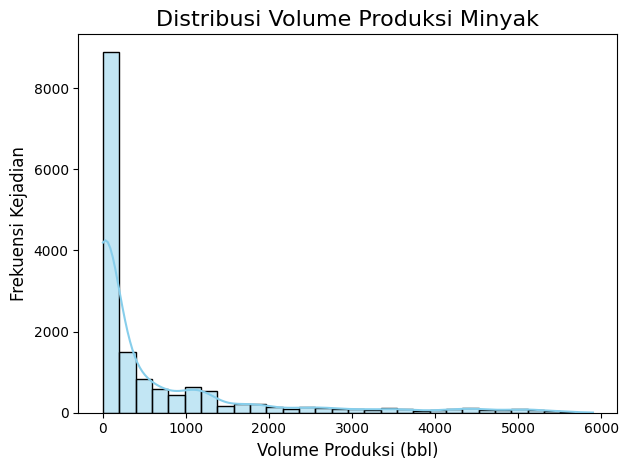

In [ ]:
sns.histplot(data=df, x='BORE_OIL_VOL', bins=30, kde=True, color='skyblue')

plt.title('Distribusi Volume Produksi Minyak', fontsize=16)
plt.xlabel('Volume Produksi (bbl)', fontsize=12)
plt.ylabel('Frekuensi Kejadian', fontsize=12)

plt.tight_layout()
plt.show()